In [1]:
# ═══════════════════════════════════════════════════
#  消融实验 — 运行核心逻辑
# ═══════════════════════════════════════════════════
import sys
from pathlib import Path

PROJ = Path.cwd().parent
sys.path.insert(0, str(PROJ / "src"))

from logistics_delay.ablation.ablation import (
    load_and_prepare_data,
    run_feature_ablation,
    run_learning_curves,
    run_geo_ablation,
    save_results,
    save_geo_results,
)
from logistics_delay.features.engineering import FEATURES_XGB, XGB_CAT_COLS
from logistics_delay.utils.paths import TABLES_DIR, FIGURES_MODELS, ensure_output_dirs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ── 最佳 CatBoost 超参数 (来自 04_tuning.ipynb) ──
BEST_CB_PARAMS = {
    "learning_rate": 0.05,
    "depth": 8,
    "iterations": 100,
    "l2_leaf_reg": 5,
    "border_count": 64,
    "bagging_temperature": 1,
    "random_strength": 0,
}

print("=" * 60)
print("  运行消融实验 — 最佳超参数版")
print(f"  参数: {BEST_CB_PARAMS}")
print("=" * 60)

df_sorted = load_and_prepare_data()

ablation_results = run_feature_ablation(
    df_sorted,
    feature_list=FEATURES_XGB,
    catboost_params=BEST_CB_PARAMS,
)
lc_results = run_learning_curves(
    df_sorted,
    feature_list=FEATURES_XGB,
    ablation_df=ablation_results,
    catboost_params=BEST_CB_PARAMS,
)
save_results(ablation_results, lc_results, save_dir=TABLES_DIR)

geo_results = run_geo_ablation(df_sorted, catboost_params=BEST_CB_PARAMS)
save_geo_results(geo_results, save_dir=TABLES_DIR)

print(f"\n特征消融: {len(ablation_results)} 行")
print(f"累积学习曲线: {len(lc_results)} 步")
print(f"地理消融: {len(geo_results)} 方案")

  运行消融实验 — 最佳超参数版
  参数: {'learning_rate': 0.05, 'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'border_count': 64, 'bagging_temperature': 1, 'random_strength': 0}
[loader] 预处理数据加载完成: (6854, 54)
[loader] 延误率: 63.19%
[data] 最终形状: (6854, 54)
[data] 正样本比例: 0.6319

  特征消融实验 (CatBoost Leave-One-Out)
[split] 训练: 5483 / 测试: 1371, spw=0.3818
[full] AUC = 83.49%  F1 = 0.7037
  去掉 TRANSPORTATION_DISTANCE_IN_KM   AUC = 84.09%  (drop=-0.60pp)  F1 = 0.6748  (drop=+2.8895pp)
  去掉 is_market                       AUC = 83.49%  (drop=+0.00pp)  F1 = 0.7037  (drop=+0.0000pp)
  去掉 start_weekday                   AUC = 84.12%  (drop=-0.63pp)  F1 = 0.7139  (drop=-1.0152pp)
  去掉 start_month                     AUC = 85.55%  (drop=-2.07pp)  F1 = 0.7305  (drop=-2.6802pp)
  去掉 planned_days_enc                AUC = 61.01%  (drop=+22.48pp)  F1 = 0.3922  (drop=+31.1547pp)
  去掉 supplier_is_large               AUC = 83.49%  (drop=+0.00pp)  F1 = 0.7037  (drop=+0.0000pp)
  去掉 vehicleType                     AUC = 83.

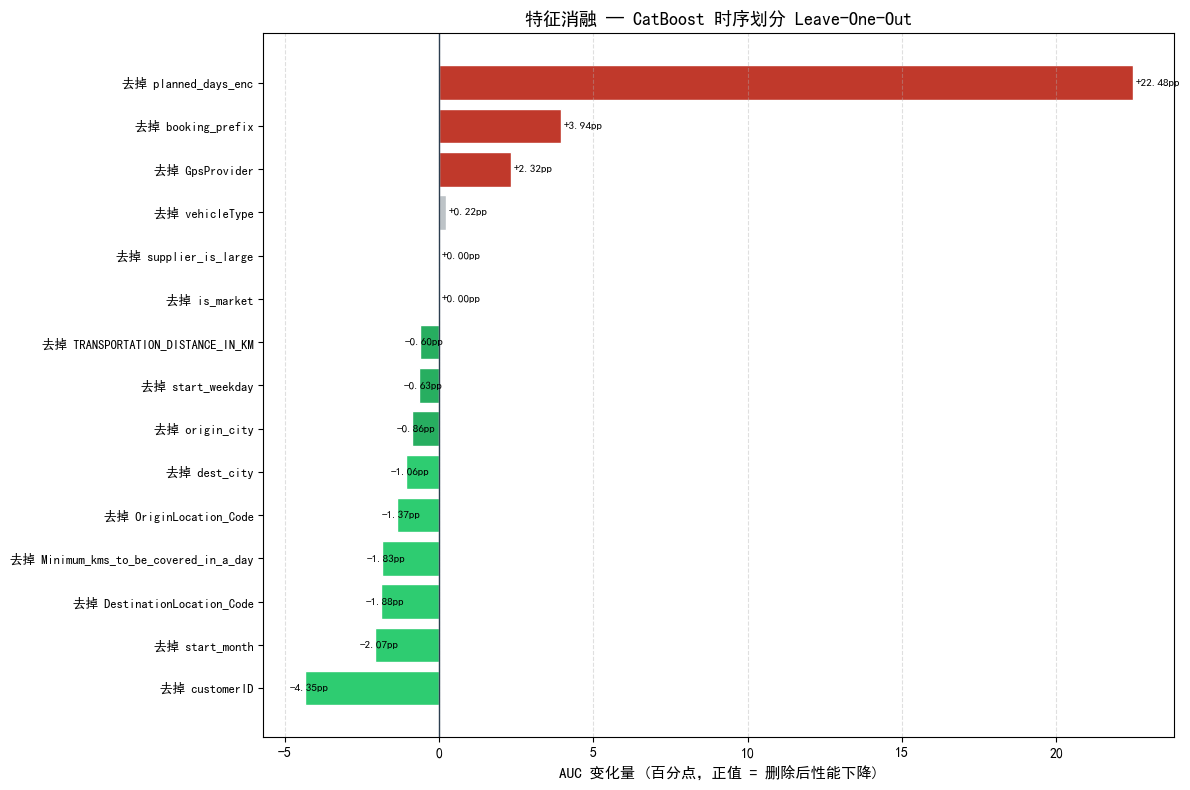

[OK] 已保存 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\feature_ablation_bar.png


In [2]:
# ═══════════════════════════════════════════════════
#  特征消融条形图 — 按 AUC 下降幅度排序
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 8))

# 去掉基准行，按 auc_drop 降序（最左为性能下降最大）
sub = ablation_results[ablation_results["removed_feat"] != "（全特征基准）"] \
    .sort_values("auc_drop", ascending=True).copy()

# 颜色映射：auc_drop > 0 = 性能下降（红），auc_drop < 0 = 性能提升（绿）
def _bar_color(val: float) -> str:
    if val > 1.0:
        return "#c0392b"   # 深红：性能显著下降
    elif val > 0.3:
        return "#e74c3c"   # 红：性能下降
    elif val > -0.3:
        return "#bdc3c7"   # 灰：几乎无影响
    elif val > -1.0:
        return "#27ae60"   # 绿：性能略有提升
    else:
        return "#2ecc71"   # 深绿：性能显著提升

colors = [_bar_color(v) for v in sub["auc_drop"]]
bars = ax.barh(range(len(sub)), sub["auc_drop"].values,
               color=colors, edgecolor="white", linewidth=1.0)

ax.axvline(0, color="#2c3e50", linestyle="-", linewidth=1)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels(["去掉 " + r["removed_feat"] for _, r in sub.iterrows()], fontsize=9)

for bar, val in zip(bars, sub["auc_drop"].values):
    x_pos = val + 0.1 if val >= 0 else val - 0.5
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}pp", va="center", fontsize=8, fontweight="bold")

ax.set_xlabel("AUC 变化量 (百分点，正值 = 删除后性能下降)", fontsize=11)
ax.set_title("特征消融 — CatBoost 时序划分 Leave-One-Out", fontsize=13, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_MODELS / "feature_ablation_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] 已保存 → {FIGURES_MODELS / 'feature_ablation_bar.png'}")

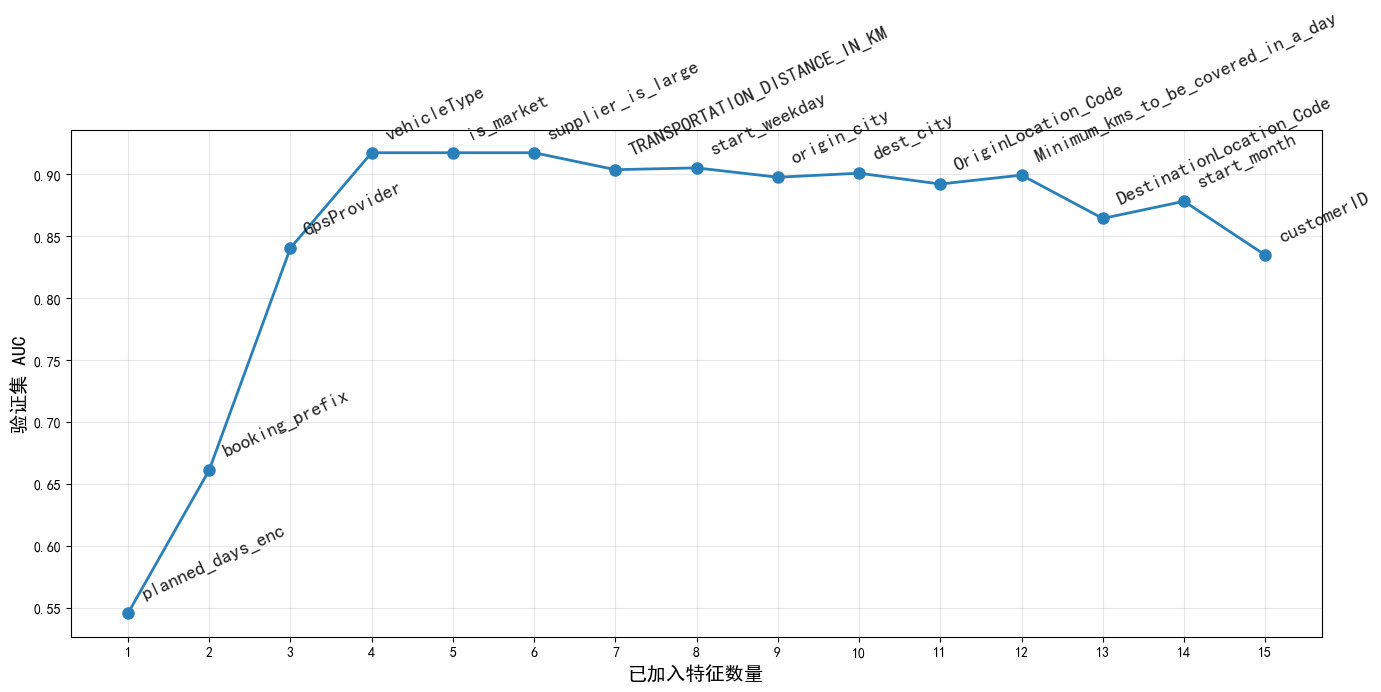

[OK] 已保存 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\learning_curves.png


In [3]:
# ═══════════════════════════════════════════════════
#  累积特征学习曲线
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(lc_results["n_features"], lc_results["auc"],
        marker="o", linestyle="-", linewidth=2, color="#2980b9", markersize=8)

# 在每个点旁标注特征名（前2个在点上方，第3个起统一在点下方避免重叠）
for i, (_, row) in enumerate(lc_results.iterrows()):
    xytext = (8, 8)  # 统一右上方偏移

    ax.annotate(
        row["feature_added"],
        xy=(row["n_features"], row["auc"]),
        xytext=xytext,
        textcoords="offset points",
        fontsize=14,
        rotation=25,
        va="bottom",
        ha="left",
        alpha=0.85
    )

ax.set_xlabel("已加入特征数量", fontsize=14)
ax.set_ylabel("验证集 AUC", fontsize=14)
ax.set_xticks(range(1, len(lc_results) + 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_MODELS / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] 已保存 → {FIGURES_MODELS / 'learning_curves.png'}")

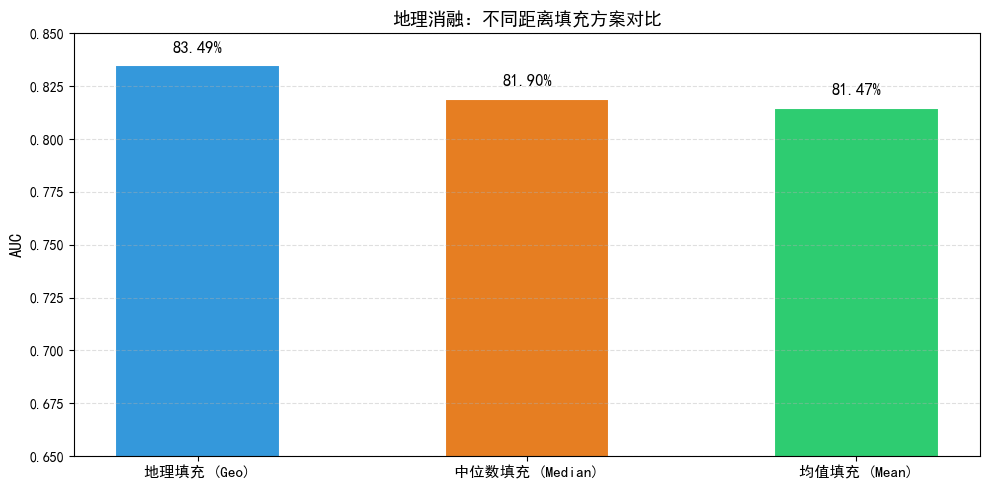

[OK] 已保存 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\figures\models\geo_ablation_bar.png


In [4]:
# ═══════════════════════════════════════════════════
#  地理消融对比
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(geo_results))
colors_geo = ["#3498db", "#e67e22", "#2ecc71"]
bars = ax.bar(x_pos, geo_results["auc"], color=colors_geo,
              edgecolor="white", linewidth=1.5, width=0.5)

for bar, auc_val in zip(bars, geo_results["auc"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{auc_val * 100:.2f}%", ha="center", va="bottom",
            fontsize=12, fontweight="bold")

ax.set_xticks(list(x_pos))
ax.set_xticklabels(geo_results["strategy"], fontsize=11)
ax.set_ylabel("AUC", fontsize=12)
ax.set_title("地理消融：不同距离填充方案对比", fontsize=13, fontweight="bold")
ax.set_ylim(0.65, 0.85)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_MODELS / "geo_ablation_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] 已保存 → {FIGURES_MODELS / 'geo_ablation_bar.png'}")